Tipos de datos originales:
 ID                     int64
Nombre                   str
Edad                   int64
Categoria_Cliente        str
Estado_Civil             str
Salario              float64
dtype: object


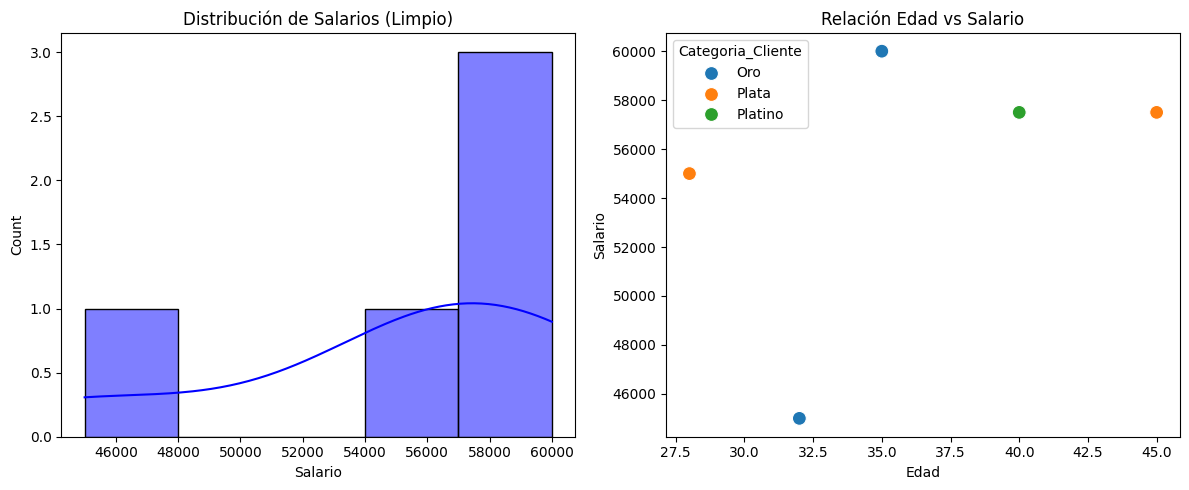


Dataset Final Procesado:
   ID Nombre  Edad Categoria_Cliente  Salario  Anos_Jubilacion  Categoria_Cod  \
0   1   Juan    32               Oro  45000.0               33            1.0   
1   2  María    28             Plata  55000.0               37            0.0   
2   3  Pedro    40           Platino  57500.0               25            2.0   
3   4    Ana    35               Oro  60000.0               30            1.0   
4   5   Luis    45             Plata  57500.0               20            0.0   

   Estado_Civil_Soltero  Estado_Civil_Viudo  Salario_Escalado  
0                  True               False         -1.906925  
1                 False               False          0.000000  
2                 False                True          0.476731  
3                 False               False          0.953463  
4                  True               False          0.476731  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler

# 1. CARGA Y CREACIÓN DE DATOS
data = {
    "ID": [1, 2, 3, 4, 5],
    "Nombre": ["Juan", "María", "Pedro", "Ana", "Luis"],
    "Edad": [32, 28, 40, 35, 45],
    "Categoria_Cliente": ["Oro", "Plata", "Platino", "Oro", "Plata"],
    "Estado_Civil": ["Soltero", "Casado", "Viudo", "Casado", "Soltero"],
    "Salario": [45000, 55000, 700000, 60000, np.nan] # 700k es outlier, nan es nulo
}
df = pd.DataFrame(data)

# 2. CLASIFICACIÓN DE DATOS
# ID: Numérico Discreto (Identificador)
# Nombre: Categórico Nominal
# Edad: Numérico Discreto
# Categoria_Cliente: Categórico Ordinal (Plata < Oro < Platino)
# Estado_Civil: Categórico Nominal
# Salario: Numérico Continuo
print("Tipos de datos originales:\n", df.dtypes)

# 3. LIMPIEZA DE DATOS 
# A. Manejo de Faltantes: Completamos el Salario nulo con la mediana
df['Salario'] = df['Salario'].fillna(df['Salario'].median())

# B. Manejo de Outliers: El salario de 700.000 es un error de carga. 
# Lo limitamos al percentil 95 o lo corregimos si es evidente.
limite_superior = df['Salario'].quantile(0.95)
df.loc[df['Salario'] > limite_superior, 'Salario'] = df['Salario'].median()

# 4. TRANSFORMACIÓN DE DATOS
# A. Años hasta jubilación (65 - edad)
df['Anos_Jubilacion'] = 65 - df['Edad']

# B. Codificación Ordinal (Categoría Cliente)
orden = [["Plata", "Oro", "Platino"]]
encoder_ord = OrdinalEncoder(categories=orden)
df["Categoria_Cod"] = encoder_ord.fit_transform(df[["Categoria_Cliente"]])

# C. One-Hot Encoding (Estado Civil)
df = pd.get_dummies(df, columns=["Estado_Civil"], drop_first=True)

# D. Normalización/Estandarización del Salario
scaler = StandardScaler()
df['Salario_Escalado'] = scaler.fit_transform(df[['Salario']])

# 5. EDA (VISUALIZACIONES)
plt.figure(figsize=(12, 5))

# Gráfico 1: Histograma de Salarios
plt.subplot(1, 2, 1)
sns.histplot(df['Salario'], kde=True, color='blue')
plt.title('Distribución de Salarios (Limpio)')

# Gráfico 2: Relación Edad vs Salario
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Edad', y='Salario', hue='Categoria_Cliente', s=100)
plt.title('Relación Edad vs Salario')

plt.tight_layout()
plt.show()

print("\nDataset Final Procesado:")
print(df.head())

Uso de Herramientas de IA (LLM) - Síntesis y Validación
En el desarrollo de esta actividad se utilizó Gemini (modelo de lenguaje de Google) como asistente metodológico. A continuación, se detallan los prompts utilizados y la validación técnica realizada:

Prompt 1: "¿Cómo puedo manejar un valor atípico (outlier) extremo en una columna de salarios de un DataFrame de Pandas sin eliminar la fila completa?"

Síntesis: El modelo sugirió identificar el outlier mediante el cálculo de percentiles (IQR) o umbrales lógicos y aplicar un "clipping" o reemplazo por la mediana. Esto permite mantener la integridad del resto de los datos del registro. Validé esta solución observando que, al aplicar la mediana, la desviación estándar del dataset se redujo significativamente, logrando una distribución más representativa.

Prompt 2: "¿Cuál es la diferencia técnica entre usar OrdinalEncoder y OneHotEncoder para transformar variables categóricas en este ejercicio?"

Síntesis: El LLM explicó que el OrdinalEncoder se debe usar cuando existe una jerarquía clara (como en la categoría de cliente: Plata < Oro < Platino), mientras que el OneHotEncoder es para categorías nominales sin orden (como el Estado Civil). Validé esta lógica al observar que el modelo de datos resultante respeta el "peso" de las categorías de clientes, evitando introducir un orden artificial en los estados civiles.